# 6. Evaluación e interpretabilidad de la corrida preliminar

**Entrada:** resultados completos del cuaderno 05. Se comprueba su integridad antes de mostrar
métricas. Esta es la etapa final del flujo de cómputo; la validación científica sigue siendo preliminar.

La cifra principal corresponde al procedimiento `selected`: selección de familia e hiperparámetros
dentro de cada CV interna, seguida de predicción externa. Las cifras por familia sirven para diagnóstico.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src' / 'experimento.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Abra el notebook desde este repositorio.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.experimento import read_config, inspect_plan, load_model_data, find_completed_run, run_experiment
from src.particiones import nested_plan
from src.modelo_baseline import build_baseline, evaluate_regression
from dataclasses import asdict

config, config_hash = read_config(ROOT / 'config' / 'model_config.yml')
X, y, trace, groups, quality, data_path, report_path = load_model_data(config)
pd.set_option('display.float_format', lambda value: f'{value:.3f}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Datos:', data_path.relative_to(ROOT))
print('Objetivo:', y.name, '[N]')

Datos: data\processed\preliminary\model_table.csv
Objetivo: First_Failure_Load_N [N]


## 6.1 Recuperar resultados comprobados

In [2]:
RUN = find_completed_run(config, config_hash, require_final=True)
if RUN is None:
    raise FileNotFoundError('Ejecute 05 o python -m src.experimento --run --fit-final')
evaluation = json.loads((RUN / 'evaluation.json').read_text(encoding='utf-8'))
manifest = json.loads((RUN / 'experiment_manifest.json').read_text(encoding='utf-8'))
metrics = pd.DataFrame(evaluation['pooled_oof_metrics']).T.rename_axis('procedimiento')
fold_metrics = pd.read_csv(RUN / 'fold_metrics.csv')
oof = pd.read_csv(RUN / 'oof_predictions.csv')
selected = oof.loc[oof['procedure'] == 'selected'].copy()
print('Corrida verificada:', RUN.relative_to(ROOT))
display(metrics)

Corrida verificada: results\20261003T021921587329Z


,mae,rmse,medae,r2
procedimiento,,,,
baseline,51.558,66.803,38.770,-0.293
ridge,12.036,15.547,9.112,0.930
elastic_net,11.490,15.048,6.946,0.934
support_vector,16.183,20.975,11.356,0.873
decision_tree,11.420,15.280,8.608,0.932
random_forest,15.730,20.517,12.054,0.878
gaussian_process,18.500,21.854,16.540,0.862
selected,9.671,12.982,7.047,0.951


## 6.2 Comparación con el baseline y estabilidad entre folds

,fold,baseline,selected,baseline_minus_selected_mae
0,1,30.013,11.288,18.725
1,2,34.042,14.531,19.511
2,3,46.486,10.393,36.093
3,4,114.318,6.292,108.026
4,5,37.242,5.526,31.716


**MAE del procedimiento: 9.67 N.** Baseline: 51.56 N. Reducción: 41.89 N.

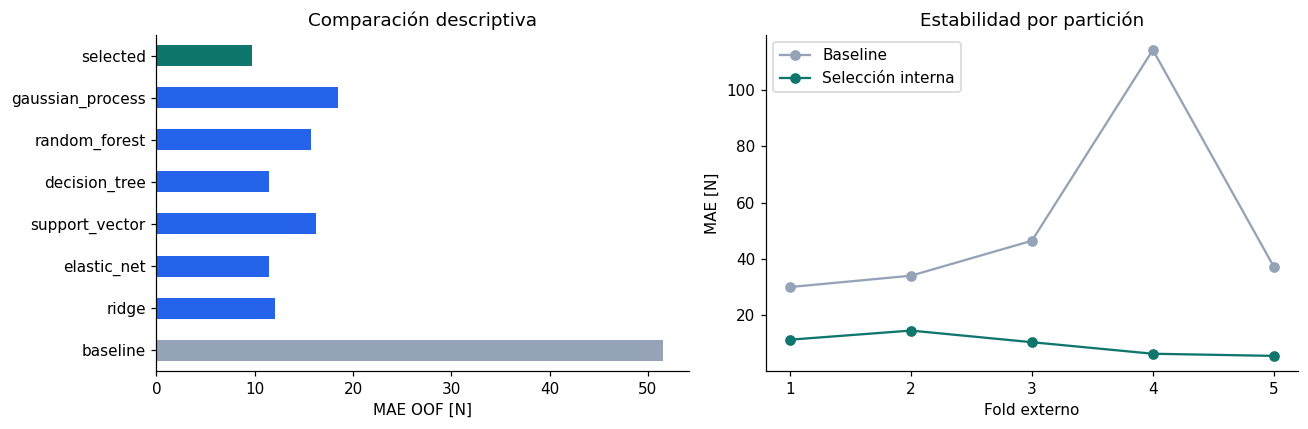

In [3]:
paired = pd.read_csv(RUN / 'paired_mae.csv')
display(paired[['fold', 'baseline', 'selected', 'baseline_minus_selected_mae']])
gain = metrics.loc['baseline', 'mae'] - metrics.loc['selected', 'mae']
display(Markdown(f"**MAE del procedimiento: {metrics.loc['selected', 'mae']:.2f} N.** "
                 f"Baseline: {metrics.loc['baseline', 'mae']:.2f} N. Reducción: {gain:.2f} N."))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics['mae'].plot.barh(ax=axes[0], color=['#94a3b8' if c == 'baseline' else '#0f766e' if c == 'selected' else '#2563eb' for c in metrics.index])
axes[0].set(xlabel='MAE OOF [N]', ylabel='', title='Comparación descriptiva')
axes[1].plot(paired['fold'], paired['baseline'], 'o-', label='Baseline', color='#94a3b8')
axes[1].plot(paired['fold'], paired['selected'], 'o-', label='Selección interna', color='#0f766e')
axes[1].set(xlabel='Fold externo', ylabel='MAE [N]', title='Estabilidad por partición', xticks=paired['fold'])
axes[1].legend(); plt.tight_layout(); plt.show()

Los entrenamientos de los folds comparten observaciones. Su dispersión describe sensibilidad a
la partición; no equivale a un intervalo de confianza basado en muestras independientes.

## 6.3 Predicciones, residuos y casos con mayor error

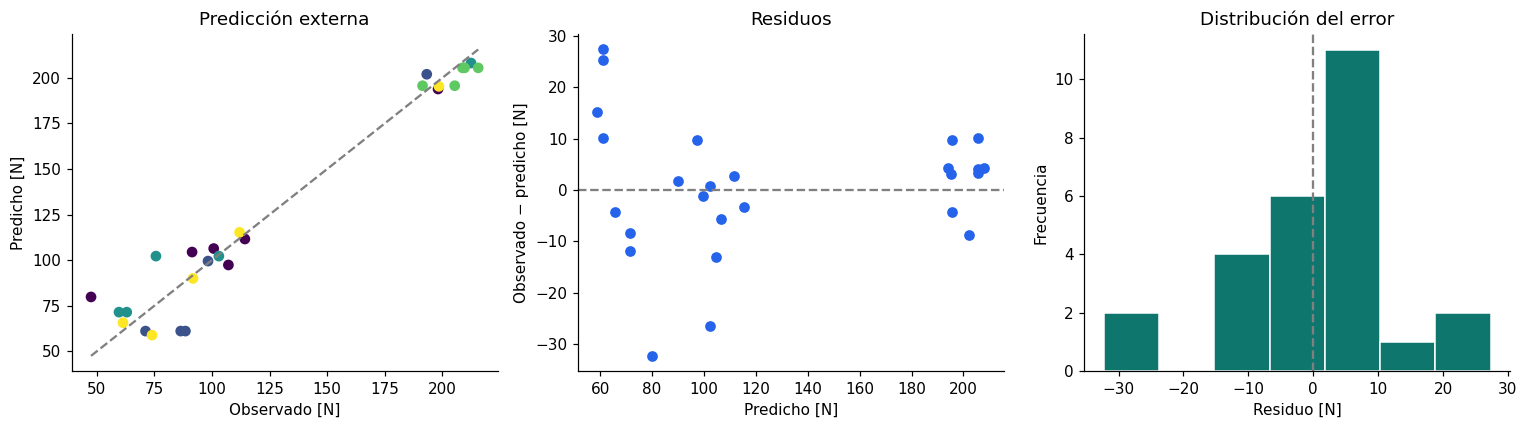

,Case_n,fold,selected_family,observed,predicted,residual,error_absoluto_N
42,1,1,elastic_net,47.550,79.857,-32.307,32.307
83,3,2,decision_tree,88.500,61.146,27.354,27.354
126,17,3,decision_tree,75.710,102.241,-26.531,26.531
84,4,2,decision_tree,86.450,61.146,25.304,25.304
203,8,5,elastic_net,74.020,58.923,15.097,15.097
45,13,1,elastic_net,91.390,104.470,-13.080,13.080
123,5,3,decision_tree,59.680,71.523,-11.843,11.843
165,22,4,decision_tree,215.520,205.450,10.070,10.070


Residuo medio: 0.47 N; positivo significa subestimación media.


In [4]:
selected['error_absoluto_N'] = selected['residual'].abs()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(selected['observed'], selected['predicted'], c=selected['fold'], cmap='viridis')
bounds = [min(selected[['observed','predicted']].min()), max(selected[['observed','predicted']].max())]
axes[0].plot(bounds, bounds, '--', color='gray')
axes[0].set(xlabel='Observado [N]', ylabel='Predicho [N]', title='Predicción externa')
axes[1].scatter(selected['predicted'], selected['residual'], color='#2563eb')
axes[1].axhline(0, linestyle='--', color='gray')
axes[1].set(xlabel='Predicho [N]', ylabel='Observado − predicho [N]', title='Residuos')
axes[2].hist(selected['residual'], bins='auto', color='#0f766e', edgecolor='white')
axes[2].axvline(0, linestyle='--', color='gray')
axes[2].set(xlabel='Residuo [N]', ylabel='Frecuencia', title='Distribución del error')
plt.tight_layout(); plt.show()
display(selected[['Case_n','fold','selected_family','observed','predicted','residual','error_absoluto_N']]
        .sort_values('error_absoluto_N', ascending=False).head(8))
print(f"Residuo medio: {selected['residual'].mean():.2f} N; positivo significa subestimación media.")

## 6.4 Interpretación y sensibilidad

La permutación mide cuánto aumenta el MAE externo al alterar una variable, después de seleccionar
el modelo. Se muestran los folds por separado porque pueden usar familias distintas. Las variables
correlacionadas y las restricciones geométricas limitan esta interpretación: permutar puede producir
combinaciones poco plausibles. Una importancia pequeña no prueba irrelevancia física.

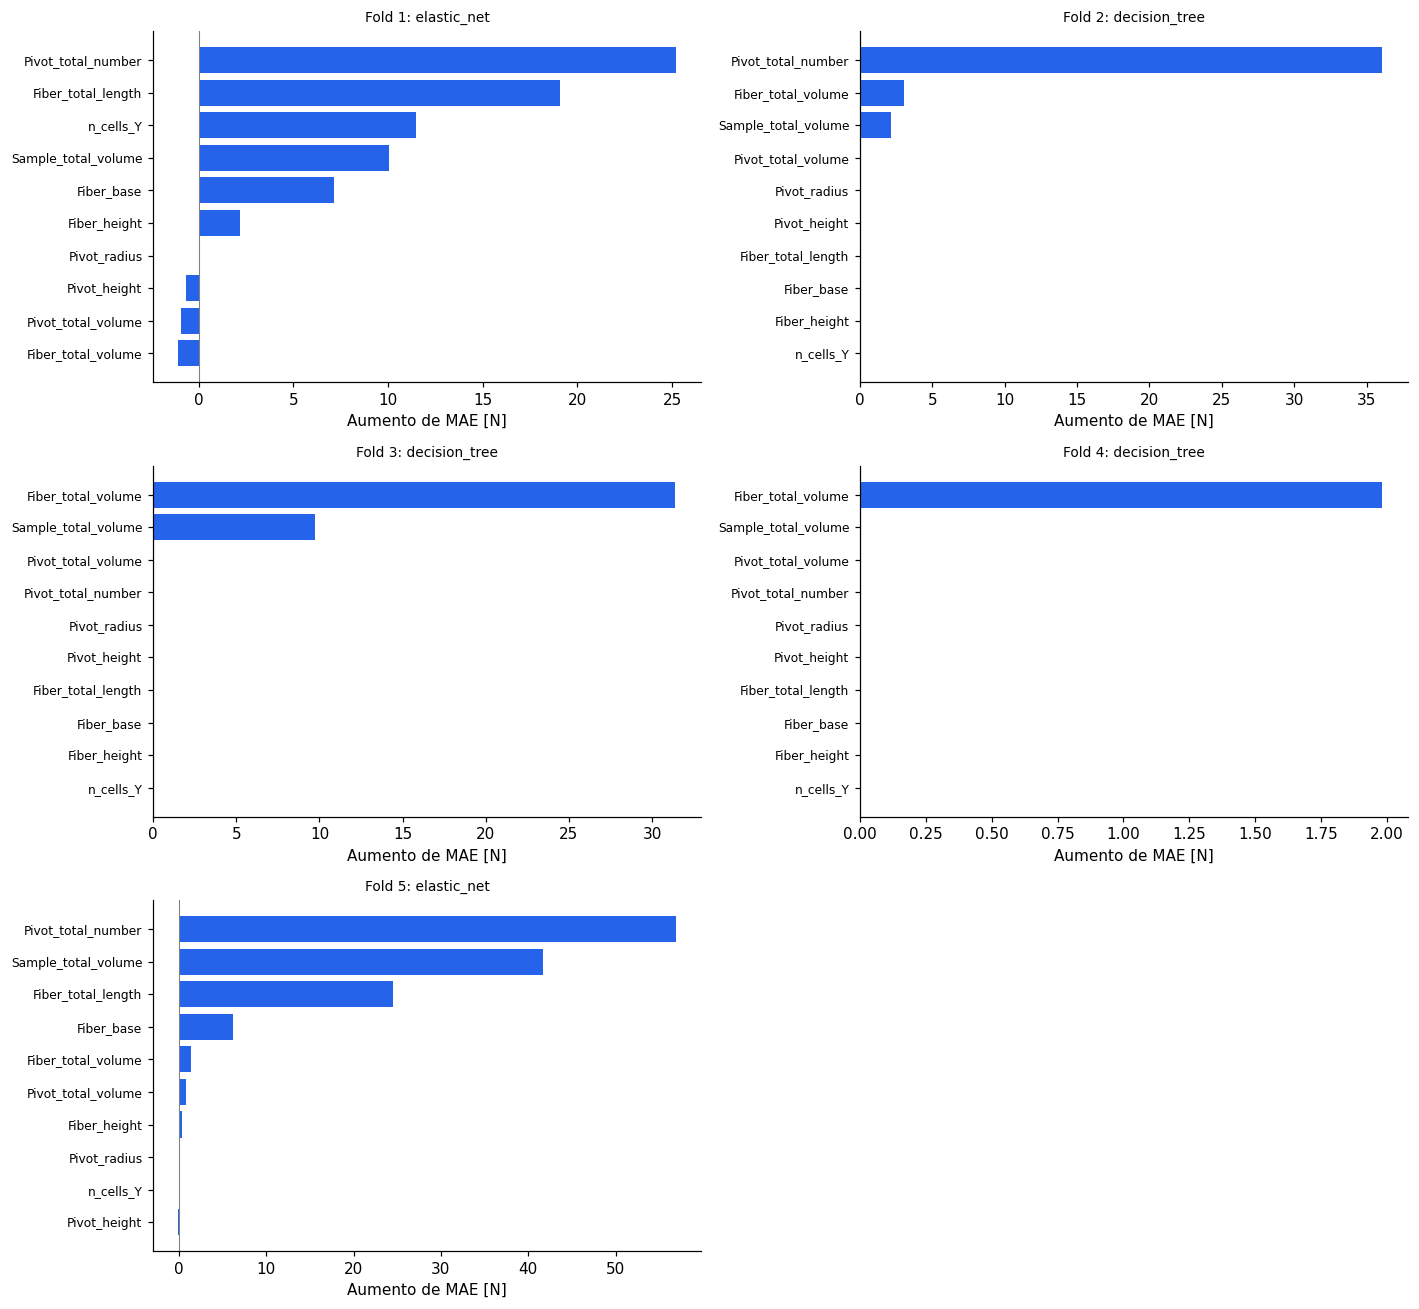

,feature,coefficient,scale,fold,familia
0,n_cells_Y,21.914,entrada estandarizada dentro del entrenamiento...,1,elastic_net
1,Fiber_height,2.933,entrada estandarizada dentro del entrenamiento...,1,elastic_net
2,Fiber_base,14.566,entrada estandarizada dentro del entrenamiento...,1,elastic_net
3,Fiber_total_length,34.900,entrada estandarizada dentro del entrenamiento...,1,elastic_net
4,Fiber_total_volume,1.939,entrada estandarizada dentro del entrenamiento...,1,elastic_net
5,Pivot_height,-5.045,entrada estandarizada dentro del entrenamiento...,1,elastic_net
6,Pivot_total_number,45.479,entrada estandarizada dentro del entrenamiento...,1,elastic_net
7,Pivot_total_volume,-1.597,entrada estandarizada dentro del entrenamiento...,1,elastic_net
8,Sample_total_volume,-36.145,entrada estandarizada dentro del entrenamiento...,1,elastic_net
9,n_cells_Y,-0.000,entrada estandarizada dentro del entrenamiento...,5,elastic_net


In [5]:
importance_frames, coefficients = [], []
for item in evaluation['selection_by_fold']:
    folder = RUN / f"fold_{item['fold']:02d}"
    imp = pd.read_csv(folder / 'selected_permutation_importance.csv')
    imp['fold'] = item['fold']; imp['familia'] = item['selected_by_inner_cv']
    importance_frames.append(imp)
    coef = pd.read_csv(folder / 'selected_coefficients.csv')
    if not coef.empty:
        coef['fold'] = item['fold']; coef['familia'] = item['selected_by_inner_cv']
        coefficients.append(coef)
importance = pd.concat(importance_frames, ignore_index=True)
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=False)
for ax, frame in zip(axes.flat, importance_frames):
    frame = frame.sort_values('mae_increase_mean')
    ax.barh(frame['feature'], frame['mae_increase_mean'], color='#2563eb')
    ax.axvline(0, color='gray', linewidth=.7)
    ax.set_title(f"Fold {frame['fold'].iloc[0]}: {frame['familia'].iloc[0]}", fontsize=9)
    ax.set_xlabel('Aumento de MAE [N]'); ax.tick_params(axis='y', labelsize=8)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()
if coefficients:
    display(pd.concat(coefficients, ignore_index=True))
else:
    print('Los modelos seleccionados no exponen coeficientes lineales.')

## 6.5 Artefacto ajustado y ejemplo de inferencia

El ejemplo comprueba que el pipeline guardado puede cargarse y predecir. Usa una geometría de la
tabla de entrenamiento; por ese motivo no se incluye como nueva evidencia de desempeño.

In [6]:
import joblib
pipeline = joblib.load(RUN / 'final_model.joblib')
final_info = json.loads((RUN / 'final_model_info.json').read_text(encoding='utf-8'))
example = X.iloc[[0]].copy()
prediction = float(pipeline.predict(example)[0])
display(example)
print('Familia reajustada:', final_info['family'])
print(f'Predicción de comprobación: {prediction:.2f} N')
print('Artefacto:', (RUN / 'final_model.joblib').relative_to(ROOT))
print(final_info['note'])

,n_cells_Y,Fiber_height,Fiber_base,Fiber_total_length,Fiber_total_volume,Pivot_height,Pivot_radius,Pivot_total_number,Pivot_total_volume,Sample_total_volume
0,4.000,1.000,2.400,2685.820,6435.300,1.000,0.500,113.000,88.710,6249.740


Familia reajustada: decision_tree
Predicción de comprobación: 68.98 N
Artefacto: results\20261003T021921587329Z\final_model.joblib
Reajuste con todos los datos; no tiene una nueva evaluación independiente


## 6.6 Exportación y conclusiones del avance

In [7]:
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)
metrics.to_csv(REPORTS / 'metricas_modelos_preliminares.csv', encoding='utf-8')
summary = {
    'status': 'preliminary_completed', 'run_id': RUN.name,
    'configuration_sha256': config_hash,
    'dataset_sha256': manifest['dataset_sha256'],
    'quality_report_sha256': manifest['quality_report_sha256'],
    'completed_at_utc': manifest['completed_at_utc'],
    'protocol': config['protocol'],
    'pooled_oof_metrics': evaluation['pooled_oof_metrics'],
    'selection_by_fold': [{'fold': s['fold'], 'family': s['selected_by_inner_cv']} for s in evaluation['selection_by_fold']],
    'refitted_family': final_info['family'],
    'refit_note': final_info['note'],
    'interpretation': evaluation['interpretation'],
}
(REPORTS / 'resumen_modelado_preliminar.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2, allow_nan=False) + chr(10), encoding='utf-8')
display(Markdown(
    f"El procedimiento de selección interna alcanza **MAE {metrics.loc['selected', 'mae']:.2f} N**, "
    f"**RMSE {metrics.loc['selected', 'rmse']:.2f} N** y **R² {metrics.loc['selected', 'r2']:.3f}** "
    f"en las predicciones externas de esta corrida. Se guardó un pipeline de la familia **{final_info['family']}** "
    "reajustado con todos los datos; sus métricas propias no se infieren de esta cifra."
))
print('Exportados: reports/metricas_modelos_preliminares.csv y reports/resumen_modelado_preliminar.json')

El procedimiento de selección interna alcanza **MAE 9.67 N**, **RMSE 12.98 N** y **R² 0.951** en las predicciones externas de esta corrida. Se guardó un pipeline de la familia **decision_tree** reajustado con todos los datos; sus métricas propias no se infieren de esta cifra.

Exportados: reports/metricas_modelos_preliminares.csv y reports/resumen_modelado_preliminar.json


La evaluación es preliminar y condicionada a la independencia entre casos de esta campaña.
La exploración previa del conjunto y la dependencia geométrica requieren una validación posterior
con datos nuevos o grupos confirmados. No se presenta como desempeño garantizado fuera del dominio.

**Reproducir:** `python -m src.experimento --run --fit-final` y luego ejecutar este cuaderno.
Los reportes CSV/JSON y los HTML quedan disponibles para revisión sin cargar archivos de modelo.